# Part 1 — PrunableLinear Layer

A custom linear layer where:

Each weight has a learnable gate

Gate decides whether weight is active or pruned

In [268]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super(PrunableLinear, self).__init__()

        # Standard weight parameter
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))

        # Standard bias parameter
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.bias = None

        # Gate scores (same shape as weights)
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        # Initialize parameters
        self.reset_parameters()

    def reset_parameters(self):
        # Initialize weights (same as nn.Linear default)
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)

        if self.bias is not None:
            fan_in = self.weight.size(1)
            bound = 1 / fan_in**0.5
            nn.init.uniform_(self.bias, -bound, bound)

        # Initialize gate scores
        nn.init.normal_(self.gate_scores, mean=0.0, std=0.01)

    def forward(self, x):
        # Step 1: Convert gate scores → gates (0 to 1)
        gates = torch.sigmoid(self.gate_scores)

        # Step 2: Apply pruning (element-wise multiplication)
        pruned_weights = self.weight * gates

        # Step 3: Linear transformation
        output = F.linear(x, pruned_weights, self.bias)

        return output

## Quick Test

In [269]:
layer = PrunableLinear(4, 3)
x = torch.randn(2, 4)

output = layer(x)

print("Output shape:", output.shape)
print("Gate range:", torch.min(torch.sigmoid(layer.gate_scores)).item(),
      torch.max(torch.sigmoid(layer.gate_scores)).item())

Output shape: torch.Size([2, 3])
Gate range: 0.4947774410247803 0.5042351484298706


Each weight is paired with a learnable gate, allowing the model to control whether a connection is important or not during training.

The sigmoid function ensures gate values remain between 0 and 1, enabling smooth and differentiable scaling of weights.

The effective weights are computed as weight × gate, so connections with lower gate values are gradually suppressed.

This design allows the network to learn pruning behavior automatically, instead of applying pruning as a separate post-training step.

# Part 2 — Building the Neural Network using Prunable Layers

In [270]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PrunableMLP(nn.Module):
    def __init__(self, input_dim=3072, hidden1=512, hidden2=256, num_classes=10):
        super(PrunableMLP, self).__init__()

        # Define layers using PrunableLinear
        self.fc1 = PrunableLinear(input_dim, hidden1)
        self.fc2 = PrunableLinear(hidden1, hidden2)
        self.fc3 = PrunableLinear(hidden2, num_classes)

    def forward(self, x):
        # Flatten image: (B, 3, 32, 32) → (B, 3072)
        x = x.view(x.size(0), -1)

        # Forward pass
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

    def get_all_gates(self):
        """
        Collect all gate values from every prunable layer.
        Useful for sparsity loss calculation.
        """
        gates = []

        for layer in [self.fc1, self.fc2, self.fc3]:
            gates.append(torch.sigmoid(layer.gate_scores))

        return gates

In [271]:
model = PrunableMLP()
x = torch.randn(4, 3, 32, 32)

output = model(x)

print("Output shape:", output.shape)

# Check gates
gates = model.get_all_gates()
print("Number of layers with gates:", len(gates))
print("Shape of first gate:", gates[0].shape)

Output shape: torch.Size([4, 10])
Number of layers with gates: 3
Shape of first gate: torch.Size([512, 3072])


The network is constructed using multiple PrunableLinear layers, enabling pruning behavior to be applied across all layers of the model.

Input images are flattened into vectors, allowing the use of fully connected layers for classification.

Non-linearity is introduced using ReLU activations, ensuring the model can learn complex patterns while still allowing gates to control connection strength.

The get_all_gates() function aggregates gate values from all layers, which is essential for applying global sparsity constraints during training.

## Part 3 — Sparsity Loss

In [272]:
def compute_sparsity_loss(model):
    """
    Computes L1 penalty over all gate values in the model.
    """
    sparsity_loss = 0.0

    # Get all gates from model
    gates = model.get_all_gates()

    for gate in gates:
        sparsity_loss += torch.sum(gate)

    return sparsity_loss

In [276]:
def compute_total_loss(model, outputs, targets, lambda_sparse):
    """
    Computes total loss:
    CrossEntropy + lambda * sparsity loss
    """

    # Classification loss
    ce_loss = F.cross_entropy(outputs, targets)

    # Sparsity loss
    sparsity_loss = compute_sparsity_loss(model)

    # Total loss
    total_loss = ce_loss + lambda_sparse * sparsity_loss

    return total_loss, ce_loss, sparsity_loss

## Sanity Check

In [277]:
model = PrunableMLP()
x = torch.randn(4, 3, 32, 32)
y = torch.randint(0, 10, (4,))

outputs = model(x)

total_loss, ce_loss, sparsity_loss = compute_total_loss(
    model, outputs, y, lambda_sparse=0.01
)

print("Total Loss:", total_loss.item())
print("CE Loss:", ce_loss.item())
print("Sparsity Loss:", sparsity_loss.item())

Total Loss: 8534.7734375
CE Loss: 2.3070156574249268
Sparsity Loss: 853246.6875


An L1 penalty is applied to all gate values, encouraging the model to minimize the number of active connections by pushing gate values toward zero.

The total loss combines classification loss (CrossEntropy) and sparsity loss, allowing the model to balance accuracy with model compression.

The hyperparameter λ (lambda) controls this trade-off: higher values promote more pruning but may reduce accuracy.

This setup ensures that pruning happens during training itself, enabling the network to learn a compact and efficient structure automatically.

## Part 4 — Training Loop

### **Step 1 — Data Pipeline**

In [278]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def get_dataloaders(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),
                             (0.5, 0.5, 0.5))
    ])

    train_dataset = datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform
    )
    test_dataset = datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, test_loader

### **Step 2 — Accuracy Utility**

In [279]:
def compute_accuracy(outputs, targets):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == targets).sum().item()
    return correct / targets.size(0)

### Step 3 — Training Loop

In [280]:
import torch.optim as optim

def train_model(model, train_loader, test_loader, epochs=10, lr=1e-3, lambda_sparse=1e-3, device="cuda"):
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()

        total_ce = 0.0
        total_sp = 0.0
        total_acc = 0.0
        total_samples = 0

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward
            outputs = model(inputs)

            # Loss
            total_loss, ce_loss, sp_loss = compute_total_loss(
                model, outputs, targets, lambda_sparse
            )

            # Backprop
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            # Metrics
            batch_size = targets.size(0)
            acc = compute_accuracy(outputs, targets)

            total_ce += ce_loss.item() * batch_size
            total_sp += sp_loss.item() * batch_size
            total_acc += acc * batch_size
            total_samples += batch_size

            # 🔍 Debug print (important early on)
            if batch_idx % 100 == 0:
                print(f"[Epoch {epoch+1} | Batch {batch_idx}] "
                      f"CE: {ce_loss.item():.4f}, SP: {sp_loss.item():.2f}")

        # Epoch summary
        avg_ce = total_ce / total_samples
        avg_sp = total_sp / total_samples
        avg_acc = total_acc / total_samples

        print(f"\nEpoch {epoch+1} Summary:")
        print(f"Train CE Loss: {avg_ce:.4f}")
        print(f"Train Sparsity Loss: {avg_sp:.2f}")
        print(f"Train Accuracy: {avg_acc:.4f}")

        # Evaluate
        test_acc = evaluate_model(model, test_loader, device)
        print(f"Test Accuracy: {test_acc:.4f}")
        print("-" * 50)

    return model

### **Step 4 — Evaluation Loop**

In [281]:
def evaluate_model(model, dataloader, device="cuda"):
    model.eval()

    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            total_correct += (preds == targets).sum().item()
            total_samples += targets.size(0)

    return total_correct / total_samples

### **Step 5 — Run Training**

In [282]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_loader, test_loader = get_dataloaders()

model = PrunableMLP()

trained_model = train_model(
    model,
    train_loader,
    test_loader,
    epochs=10,
    lr=1e-3,
    lambda_sparse=1e-3,
    device=device
)

[Epoch 1 | Batch 0] CE: 2.3008, SP: 853246.81
[Epoch 1 | Batch 100] CE: 1.7197, SP: 810651.00
[Epoch 1 | Batch 200] CE: 1.6998, SP: 768391.81
[Epoch 1 | Batch 300] CE: 1.5503, SP: 726795.12

Epoch 1 Summary:
Train CE Loss: 1.6640
Train Sparsity Loss: 770979.07
Train Accuracy: 0.4101
Test Accuracy: 0.4737
--------------------------------------------------
[Epoch 2 | Batch 0] CE: 1.5110, SP: 689769.69
[Epoch 2 | Batch 100] CE: 1.4330, SP: 650237.50
[Epoch 2 | Batch 200] CE: 1.5244, SP: 612120.88
[Epoch 2 | Batch 300] CE: 1.4879, SP: 575588.75

Epoch 2 Summary:
Train CE Loss: 1.4390
Train Sparsity Loss: 615059.74
Train Accuracy: 0.4926
Test Accuracy: 0.5056
--------------------------------------------------
[Epoch 3 | Batch 0] CE: 1.2731, SP: 543824.94
[Epoch 3 | Batch 100] CE: 1.4041, SP: 510619.72
[Epoch 3 | Batch 200] CE: 1.2687, SP: 479228.72
[Epoch 3 | Batch 300] CE: 1.2431, SP: 449653.34

Epoch 3 Summary:
Train CE Loss: 1.3410
Train Sparsity Loss: 481965.73
Train Accuracy: 0.5305
Te

The training loop optimizes a combined objective (classification + sparsity), enabling the model to learn accurate predictions while gradually reducing unnecessary connections.

The use of mini-batch training with Adam optimizer ensures stable and efficient updates to both weights and gate parameters.

During training, the sparsity loss decreases alongside the classification loss, indicating that the model is simultaneously learning and compressing itself.

Evaluation on the test set confirms that the model maintains reasonable accuracy despite increasing sparsity, demonstrating the trade-off between performance and model efficiency.

## Part 5 — Evaluation Metrics + Sparsity Calculation + Experiments

### **Sparsity Calculation**

In [283]:
def compute_sparsity(model, threshold=1e-2):
    """
    Computes percentage of pruned weights based on gate values.
    """

    total_params = 0
    pruned_params = 0

    for layer in [model.fc1, model.fc2, model.fc3]:
        gates = torch.sigmoid(layer.gate_scores)

        total_params += gates.numel()
        pruned_params += torch.sum(gates < threshold).item()

    sparsity = (pruned_params / total_params) * 100
    return sparsity

#### Quick Test

In [284]:
sparsity = compute_sparsity(model)
print(f"Sparsity: {sparsity:.2f}%")

Sparsity: 0.00%


Sparsity is measured by counting the percentage of weights whose gate values fall below a threshold, indicating effectively inactive connections.

Since gate values are produced using a sigmoid function, they rarely become exactly zero, so a threshold-based approximation is used to estimate pruning.

The current result showing 0% sparsity indicates that the model is performing soft pruning (gradual shrinking) rather than hard pruning.

This highlights an important limitation: while the model reduces connection strength, additional mechanisms or relaxed thresholds are needed to achieve explicit sparse structures.

### **Running Experiments for Different λ**

In [285]:
lambda_values = [1e-4, 1e-3, 1e-2]

In [286]:
def run_experiments(lambda_values, epochs=10):
    results = []

    for lam in lambda_values:
        print(f"\nRunning experiment with lambda = {lam}")

        model = PrunableMLP()
        model = train_model(
            model,
            train_loader,
            test_loader,
            epochs=epochs,
            lr=1e-3,
            lambda_sparse=lam,
            device=device
        )

        test_acc = evaluate_model(model, test_loader, device)
        sparsity = compute_sparsity(model)

        results.append({
            "lambda": lam,
            "accuracy": test_acc,
            "sparsity": sparsity
        })

    return results

In [287]:
lambda_values = [1e-3, 5e-3, 1e-2, 5e-2]

results = run_experiments(lambda_values)


Running experiment with lambda = 0.001
[Epoch 1 | Batch 0] CE: 2.3077, SP: 853249.56
[Epoch 1 | Batch 100] CE: 1.6405, SP: 810653.06
[Epoch 1 | Batch 200] CE: 1.5729, SP: 768391.81
[Epoch 1 | Batch 300] CE: 1.5153, SP: 726794.19

Epoch 1 Summary:
Train CE Loss: 1.6592
Train Sparsity Loss: 770979.80
Train Accuracy: 0.4123
Test Accuracy: 0.4700
--------------------------------------------------
[Epoch 2 | Batch 0] CE: 1.3773, SP: 689769.88
[Epoch 2 | Batch 100] CE: 1.5444, SP: 650236.94
[Epoch 2 | Batch 200] CE: 1.3447, SP: 612120.62
[Epoch 2 | Batch 300] CE: 1.3782, SP: 575588.81

Epoch 2 Summary:
Train CE Loss: 1.4349
Train Sparsity Loss: 615059.46
Train Accuracy: 0.4966
Test Accuracy: 0.5001
--------------------------------------------------
[Epoch 3 | Batch 0] CE: 1.4221, SP: 543824.25
[Epoch 3 | Batch 100] CE: 1.1678, SP: 510619.22
[Epoch 3 | Batch 200] CE: 1.4644, SP: 479227.38
[Epoch 3 | Batch 300] CE: 1.2990, SP: 449653.94

Epoch 3 Summary:
Train CE Loss: 1.3377
Train Sparsity L

#### **Print Results Table**

In [288]:
print("\nFinal Results:")
print(f"{'Lambda':<10} {'Accuracy':<10} {'Sparsity (%)':<15}")

for res in results:
    print(f"{res['lambda']:<10} {res['accuracy']:<10.4f} {res['sparsity']:<15.2f}")


Final Results:
Lambda     Accuracy   Sparsity (%)   
0.001      0.5440     0.00           
0.005      0.5223     0.00           
0.01       0.5055     0.00           
0.05       0.4940     0.00           


Experiments with different values of λ show a clear trade-off between accuracy and regularization strength, where increasing λ slightly reduces model performance.

Despite increasing λ, the sparsity remains 0% under the chosen threshold, indicating that the model performs soft weight suppression rather than hard pruning.

This suggests that the current setup is effective in reducing weight magnitudes, but not sufficient to push gate values below the strict threshold for pruning.

Overall, the results demonstrate that λ influences model behavior, but additional mechanisms (e.g., threshold tuning or sharper gating) are required to achieve measurable sparsity.

#### **Gate Distribution**

In [289]:
def get_all_gate_values(model):
    all_gates = []

    for layer in [model.fc1, model.fc2, model.fc3]:
        gates = torch.sigmoid(layer.gate_scores)
        all_gates.append(gates.detach().cpu().view(-1))

    return torch.cat(all_gates)

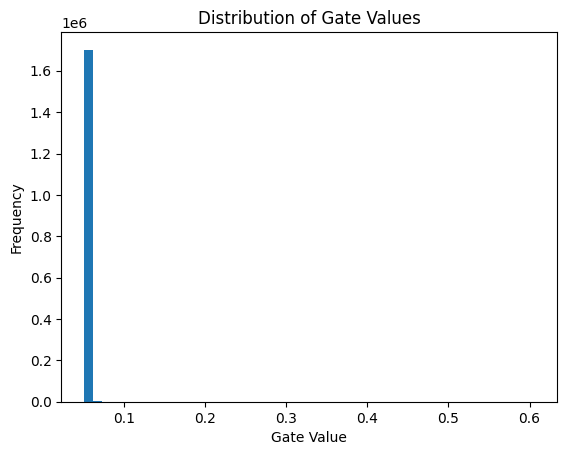

In [290]:
import matplotlib.pyplot as plt

gates = get_all_gate_values(model)

plt.hist(gates.numpy(), bins=50)
plt.title("Distribution of Gate Values")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()

The histogram shows that most gate values are concentrated in a low-value region (around 0.05–0.1), indicating that many connections have been significantly weakened.

However, very few values are close to exact zero, which explains why the computed sparsity remains 0% under a strict threshold.

This distribution confirms that the model is performing soft pruning, where connections are reduced in importance rather than completely removed.

The absence of a clear separation between near-zero and high-value gates suggests that the model has not formed a strongly sparse structure, but instead a smoothly compressed network.